In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [5]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Return Rate\data\สรุปยอดขาย Lineman.xlsx"
df = pd.read_excel(file_path)

In [6]:
df.head()

,Date,Day Name,Week of Month,Sales,Ads
0,2025-01-10,Friday,2,104.00,0.0
1,2025-01-12,Sunday,3,357.00,0.0
2,2025-01-13,Monday,3,279.04,0.0
3,2025-01-16,Thursday,3,457.00,0.0
4,2025-01-17,Friday,3,298.00,0.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           215 non-null    datetime64[us]
 1   Day Name       215 non-null    str           
 2   Week of Month  215 non-null    int64         
 3   Sales          215 non-null    float64       
 4   Ads            215 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 8.5 KB


In [8]:
df["Week of Month"] = df["Week of Month"].replace(6, 5)
df["Week of Month"] = df["Week of Month"].astype(str)

In [13]:
df = df[df["Day Name"] != "Saturday"]

In [14]:
df.describe()

,Date,Sales,Ads
count,213,213.000000,213.000000
mean,2025-07-25 18:15:12.676056,520.009484,39.608122
min,2025-01-10 00:00:00,0.000000,0.000000
25%,2025-04-08 00:00:00,243.000000,0.000000
50%,2025-07-25 00:00:00,441.000000,0.000000
75%,2025-11-12 00:00:00,726.000000,0.000000
max,2026-01-30 00:00:00,1753.700000,321.000000
std,NaN,355.158225,75.535248


In [15]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

Day Name: 6
Week of Month: 5


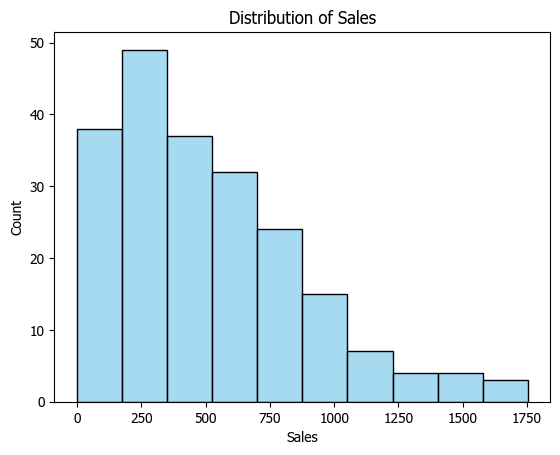

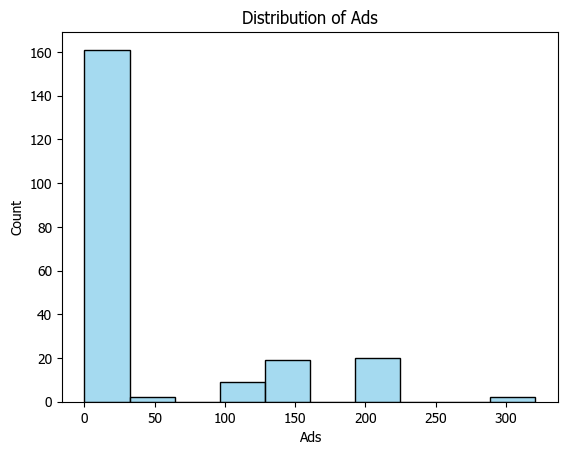

In [16]:
for col in df.select_dtypes(include="number").columns:
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=10, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

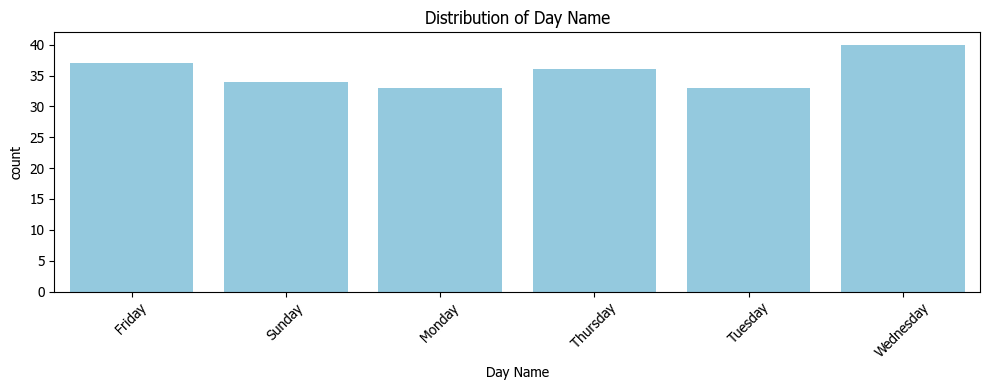

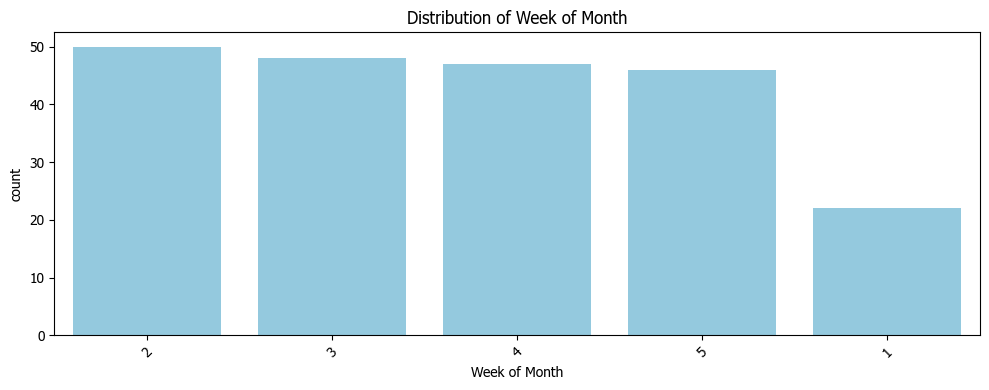

In [17]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]).columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [18]:
print("--- รายงานผลการทดสอบ Normality (ความเป็นเส้นโค้งปกติ) ---")
print("สมมติฐานหลัก (H0): ข้อมูลมีการแจกแจงเป็นเส้นโค้งปกติ (Normal Distribution)\n")

# วนลูปทดสอบเฉพาะคอลัมน์ที่เป็นตัวเลข
for col in df.select_dtypes(include="number").columns:
    # ตัดค่า null ออกก่อนทดสอบ
    data_clean = df[col].dropna()

    # ตรวจสอบจำนวนข้อมูลเบื้องต้น
    if len(data_clean) < 3:
        continue

    # ใช้ D'Agostino's K-squared Test (เหมาะสำหรับข้อมูลขนาดใหญ่)
    stat, p_value = stats.normaltest(data_clean)

    # คำนวณค่า Kurtosis (ความโด่ง) เพิ่มเติมเพื่อใช้เขียนคู่กับ Skewness
    kurt_val = data_clean.kurtosis()
    skew_val = data_clean.skew()

    print(f"คอลัมน์: {col}")
    print(f"  - ค่า Skewness (ความเบ้): {skew_val:.4f}")
    print(f"  - ค่า Kurtosis (ความโด่ง): {kurt_val:.4f}")
    print(f"  - p-value จาก Normality Test: {p_value:.4e}")

    # แปลผลทางสถิติด้วยค่า p-value (Alpha = 0.05)
    if p_value > 0.05:
        print(
            "  -> สรุปผล: ยอมรับ H0 ข้อมูลมี การแจกแจงเป็นปกติ (Normal Distribution) อย่างมีนัยสำคัญ"
        )
    else:
        print(
            "  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ"
        )
    print("-" * 65)

--- รายงานผลการทดสอบ Normality (ความเป็นเส้นโค้งปกติ) ---
สมมติฐานหลัก (H0): ข้อมูลมีการแจกแจงเป็นเส้นโค้งปกติ (Normal Distribution)

คอลัมน์: Sales
  - ค่า Skewness (ความเบ้): 1.0425
  - ค่า Kurtosis (ความโด่ง): 0.8581
  - p-value จาก Normality Test: 5.5170e-08
  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ
-----------------------------------------------------------------
คอลัมน์: Ads
  - ค่า Skewness (ความเบ้): 1.7299
  - ค่า Kurtosis (ความโด่ง): 1.8350
  - p-value จาก Normality Test: 6.9575e-16
  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ
-----------------------------------------------------------------


In [19]:
import pandas as pd
import scipy.stats as stats

# 1. คัดแยกประเภทคอลัมน์อัตโนมัติ
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns
numeric_cols = df.select_dtypes(include=["number"]).columns

print("==================================================================")
# สแกนหาความแปรปรวนแบบจับคู่ตัดขวาง
print("📢 เริ่มการทดสอบ Levene's Test ทุกคู่ปัจจัย (X-Categorical vs Y-Numeric)")
print("==================================================================\n")

# วนลูปตามตัวแปรตาม (Y) ที่เป็นตัวเลขก่อน
for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ตัวแปรตาม Y: {y_col}]")
    print("=" * 66)

    # วนลูปตามตัวแปรต้น (X) ที่เป็นข้อความมาจับคู่
    for x_col in categorical_cols:
        # ข้ามคอลัมน์วันที่เพื่อป้องกันข้อผิดพลาดเชิงสถิติ
        if "date" in x_col.lower():
            continue

        # จัดกลุ่มข้อมูล Y ตามประเภทของ X และตัดค่าว่างออก
        groups = [
            group[y_col].dropna()
            for name, group in df.groupby(x_col)
            if len(group[y_col].dropna()) > 0
        ]

        # เช็คเงื่อนไขความสมบูรณ์ของกลุ่มย่อย
        if len(groups) < 2:
            print(
                f"⚠️ คู่ [{x_col}] vs [{y_col}]: กลุ่มย่อยมีน้อยกว่า 2 กลุ่ม ไม่สามารถทดสอบได้"
            )
            print("-" * 66)
            continue

        # รันสถิติ Levene's Test
        stat, p_value = stats.levene(*groups)

        print(f" 👉 ตัวแปรต้น (X): {x_col}")
        print(f"    - ค่าสถิติ (Statistic): {stat:.4f}")
        print(f"    - p-value: {p_value:.4e}")

        # แปลผลลัพธ์เพื่อนำไปเลือกโมเดลต่อ
        if p_value > 0.05:
            print(
                "    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ (ผ่านเกณฑ์ ใช้ ANOVA / t-test ปกติ)"
            )
        else:
            print(
                "    -> สรุปผล: p < 0.05 ความแปรปรวน 'ไม่เท่ากัน' ❌ (ต้องเลี่ยงไปใช้ Welch's ANOVA / Welch's t-test)"
            )
        print("-" * 66)
    print("\n" + "=" * 66 + "\n")

📢 เริ่มการทดสอบ Levene's Test ทุกคู่ปัจจัย (X-Categorical vs Y-Numeric)

🎯 [วิเคราะห์ตัวแปรตาม Y: Sales]
 👉 ตัวแปรต้น (X): Day Name
    - ค่าสถิติ (Statistic): 0.3471
    - p-value: 8.8373e-01
    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ (ผ่านเกณฑ์ ใช้ ANOVA / t-test ปกติ)
------------------------------------------------------------------
 👉 ตัวแปรต้น (X): Week of Month
    - ค่าสถิติ (Statistic): 1.0944
    - p-value: 3.6036e-01
    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ (ผ่านเกณฑ์ ใช้ ANOVA / t-test ปกติ)
------------------------------------------------------------------


🎯 [วิเคราะห์ตัวแปรตาม Y: Ads]
 👉 ตัวแปรต้น (X): Day Name
    - ค่าสถิติ (Statistic): 0.2450
    - p-value: 9.4195e-01
    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ (ผ่านเกณฑ์ ใช้ ANOVA / t-test ปกติ)
------------------------------------------------------------------
 👉 ตัวแปรต้น (X): Week of Month
    - ค่าสถิติ (Statistic): 0.9913
    - p-value: 4.1329e-01
    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ 

In [20]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

# คัดเลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (Y) ทั้งหมดใน DataFrame
numeric_cols = df.select_dtypes(include=["number"]).columns

print("=========================================================")
print(f"📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y {list(numeric_cols)}")
print("=========================================================\n")

# วนลูปประมวลผลแยกตามตัวแปรตาม (Y) ทีละตัว
for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: {y_col} แยกตาม Day Name]")
    print("=" * 65)

    print(f" 1. สถิติเบื้องต้นของ {y_col} แบ่งตาม Day Name")
    print("-" * 65)
    desc_stats = df.groupby("Day Name")[y_col].agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    desc_stats = desc_stats.sort_values(by="mean", ascending=False)
    print(
        desc_stats.to_string(
            formatters={"mean": "{:,.2f}".format, "std": "{:,.2f}".format}
        )
    )
    print("\n")

    print(f" 2. ANOVA Table (Y: {y_col})")
    print("-" * 65)
    # ใช้ Q() เพื่อรองรับชื่อคอลัมน์ Day Name ที่มีเว้นวรรค
    formula = f"Q('{y_col}') ~ C(Q('Day Name'))"
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # ดึงค่า p-value ของกลุ่มปัจจัยออกมารายงาน
    p_value = anova_table.iloc[0]["PR(>F)"]
    print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
    print("-" * 65 + "\n")

    # ถ้า p-value มีนัยสำคัญ (< 0.05) ให้ลุยขั้นตอนจัดกลุ่มตัวอักษรต่อทันที
    if p_value < 0.05:
        print(f" 3. Post-hoc Analysis & Group Letters (Tukey HSD) ของ {y_col}")
        print("-" * 65)

        # เคลียร์ค่าว่างเฉพาะคู่ตัวแปรเพื่อไม่ให้โมเดลพัง
        df_clean = df[["Day Name", y_col]].dropna()

        mc = MultiComparison(df_clean[y_col], df_clean["Day Name"])
        tukey_result = mc.tukeyhsd()

        print("--- ผลการเปรียบเทียบรายคู่ ---")
        print(tukey_result.summary())
        print("\n")

        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print(
            "เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'"
        )
        print("---------------------------------------------------------")

        means = df_clean.groupby("Day Name")[y_col].mean()
        sorted_groups = means.sort_values(ascending=False).index.tolist()

        tukey_df = pd.DataFrame(
            tukey_result.summary().data[1:],
            columns=tukey_result.summary().data[0],
        )

        adj_matrix = pd.DataFrame(
            False, index=sorted_groups, columns=sorted_groups
        )
        for _, row in tukey_df.iterrows():
            g1 = str(row["group1"])
            g2 = str(row["group2"])
            reject = bool(row["reject"])
            if g1 in sorted_groups and g2 in sorted_groups:
                adj_matrix.loc[g1, g2] = not reject
                adj_matrix.loc[g2, g1] = not reject

        for g in sorted_groups:
            adj_matrix.loc[g, g] = True

        clique_list = []
        for g in sorted_groups:
            connected = adj_matrix.index[adj_matrix[g]].tolist()
            for i in range(len(connected)):
                for j in range(i + 1, len(connected)):
                    if not adj_matrix.loc[connected[i], connected[j]]:
                        connected.remove(connected[j])
                        break
            clique = sorted(list(set(connected)))
            if clique not in clique_list:
                clique_list.append(clique)

        for i in range(len(clique_list) - 1, -1, -1):
            for j in range(len(clique_list)):
                if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                    clique_list.pop(i)
                    break

        clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

        letters = {g: "" for g in sorted_groups}
        for idx, clique in enumerate(clique_list):
            letter = chr(ord("a") + idx)
            for g in clique:
                letters[g] += letter

        rank_summary = df_clean.groupby("Day Name")[y_col].mean().reset_index()
        rank_summary["Day Name_STR"] = rank_summary["Day Name"].astype(str)
        rank_summary["Group Sign"] = rank_summary["Day Name_STR"].map(letters)
        rank_summary = rank_summary.sort_values(by=y_col, ascending=False).reset_index(
            drop=True
        )
        rank_summary.index = rank_summary.index + 1
        rank_summary.index.name = "Rank (Mean มากสุด)"

        rank_summary = rank_summary[["Day Name", y_col, "Group Sign"]]
        rank_summary.columns = [
            "Day Name Status (Day Name)",
            f"Mean {y_col}",
            "Statistical Group",
        ]

        print(
            rank_summary.to_string(
                formatters={f"Mean {y_col}": "{:,.4f}".format}
            )
        )
        print("---------------------------------------------------------")

    else:
        print(
            f"ผลการทดสอบ ANOVA ของ {y_col} ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ"
        )

    print("\n" + "=" * 65 + "\n")

📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y ['Sales', 'Ads']

🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: Sales แยกตาม Day Name]
 1. สถิติเบื้องต้นของ Sales แบ่งตาม Day Name
-----------------------------------------------------------------
           count   mean    std     min   median      max
Day Name                                                
Tuesday       33 591.06 362.89    0.00  541.350  1753.70
Monday        33 542.67 359.79    0.00  514.000  1411.00
Sunday        34 535.99 393.27  111.00  409.500  1626.90
Thursday      36 511.66 339.91  118.22  449.000  1454.45
Friday        37 491.63 394.45  104.00  343.000  1610.06
Wednesday     40 462.88 290.05    0.00  429.785  1103.00


 2. ANOVA Table (Y: Sales)
-----------------------------------------------------------------
                        sum_sq     df         F    PR(>F)
C(Q('Day Name'))  3.550657e+05    5.0  0.557102  0.732798
Residual          2.638606e+07  207.0       NaN       NaN

p-value ของ ANOVA คือ: 0.7328
-------------

In [21]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

# คัดเลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (Y) ทั้งหมดใน DataFrame
numeric_cols = df.select_dtypes(include=["number"]).columns

print("=========================================================")
print(f"📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y {list(numeric_cols)}")
print("=========================================================\n")

# วนลูปประมวลผลแยกตามตัวแปรตาม (Y) ทีละตัว
for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: {y_col} แยกตาม Day Name]")
    print("=" * 65)

    print(f" 1. สถิติเบื้องต้นของ {y_col} แบ่งตาม Day Name")
    print("-" * 65)
    desc_stats = df.groupby("Day Name")[y_col].agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    desc_stats = desc_stats.sort_values(by="mean", ascending=False)
    print(
        desc_stats.to_string(
            formatters={"mean": "{:,.2f}".format, "std": "{:,.2f}".format}
        )
    )
    print("\n")

    print(f" 2. ANOVA Table (Y: {y_col})")
    print("-" * 65)
    # ใช้ Q() เพื่อรองรับชื่อคอลัมน์ Day Name ที่มีเว้นวรรค
    formula = f"Q('{y_col}') ~ C(Q('Day Name'))"
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # ดึงค่า p-value ของกลุ่มปัจจัยออกมารายงาน
    p_value = anova_table.iloc[0]["PR(>F)"]
    print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
    print("-" * 65 + "\n")

    # ถ้า p-value มีนัยสำคัญ (< 0.05) ให้ลุยขั้นตอนจัดกลุ่มตัวอักษรต่อทันที
    if p_value < 0.05:
        print(f" 3. Post-hoc Analysis & Group Letters (Tukey HSD) ของ {y_col}")
        print("-" * 65)

        # เคลียร์ค่าว่างเฉพาะคู่ตัวแปรเพื่อไม่ให้โมเดลพัง
        df_clean = df[["Day Name", y_col]].dropna()

        mc = MultiComparison(df_clean[y_col], df_clean["Day Name"])
        tukey_result = mc.tukeyhsd()

        print("--- ผลการเปรียบเทียบรายคู่ ---")
        print(tukey_result.summary())
        print("\n")

        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print(
            "เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'"
        )
        print("---------------------------------------------------------")

        means = df_clean.groupby("Day Name")[y_col].mean()
        sorted_groups = means.sort_values(ascending=False).index.tolist()

        tukey_df = pd.DataFrame(
            tukey_result.summary().data[1:],
            columns=tukey_result.summary().data[0],
        )

        adj_matrix = pd.DataFrame(
            False, index=sorted_groups, columns=sorted_groups
        )
        for _, row in tukey_df.iterrows():
            g1 = str(row["group1"])
            g2 = str(row["group2"])
            reject = bool(row["reject"])
            if g1 in sorted_groups and g2 in sorted_groups:
                adj_matrix.loc[g1, g2] = not reject
                adj_matrix.loc[g2, g1] = not reject

        for g in sorted_groups:
            adj_matrix.loc[g, g] = True

        clique_list = []
        for g in sorted_groups:
            connected = adj_matrix.index[adj_matrix[g]].tolist()
            for i in range(len(connected)):
                for j in range(i + 1, len(connected)):
                    if not adj_matrix.loc[connected[i], connected[j]]:
                        connected.remove(connected[j])
                        break
            clique = sorted(list(set(connected)))
            if clique not in clique_list:
                clique_list.append(clique)

        for i in range(len(clique_list) - 1, -1, -1):
            for j in range(len(clique_list)):
                if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                    clique_list.pop(i)
                    break

        clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

        letters = {g: "" for g in sorted_groups}
        for idx, clique in enumerate(clique_list):
            letter = chr(ord("a") + idx)
            for g in clique:
                letters[g] += letter

        rank_summary = df_clean.groupby("Day Name")[y_col].mean().reset_index()
        rank_summary["Day Name_STR"] = rank_summary["Day Name"].astype(str)
        rank_summary["Group Sign"] = rank_summary["Day Name_STR"].map(letters)
        rank_summary = rank_summary.sort_values(by=y_col, ascending=False).reset_index(
            drop=True
        )
        rank_summary.index = rank_summary.index + 1
        rank_summary.index.name = "Rank (Mean มากสุด)"

        rank_summary = rank_summary[["Day Name", y_col, "Group Sign"]]
        rank_summary.columns = [
            "Day Name Status (Day Name)",
            f"Mean {y_col}",
            "Statistical Group",
        ]

        print(
            rank_summary.to_string(
                formatters={f"Mean {y_col}": "{:,.4f}".format}
            )
        )
        print("---------------------------------------------------------")

    else:
        print(
            f"ผลการทดสอบ ANOVA ของ {y_col} ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ"
        )

    print("\n" + "=" * 65 + "\n")

📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y ['Sales', 'Ads']

🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: Sales แยกตาม Day Name]
 1. สถิติเบื้องต้นของ Sales แบ่งตาม Day Name
-----------------------------------------------------------------
           count   mean    std     min   median      max
Day Name                                                
Tuesday       33 591.06 362.89    0.00  541.350  1753.70
Monday        33 542.67 359.79    0.00  514.000  1411.00
Sunday        34 535.99 393.27  111.00  409.500  1626.90
Thursday      36 511.66 339.91  118.22  449.000  1454.45
Friday        37 491.63 394.45  104.00  343.000  1610.06
Wednesday     40 462.88 290.05    0.00  429.785  1103.00


 2. ANOVA Table (Y: Sales)
-----------------------------------------------------------------
                        sum_sq     df         F    PR(>F)
C(Q('Day Name'))  3.550657e+05    5.0  0.557102  0.732798
Residual          2.638606e+07  207.0       NaN       NaN

p-value ของ ANOVA คือ: 0.7328
-------------

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# คัดเลือกคอลัมน์ตัวเลขทั้งหมด
numeric_cols = df.select_dtypes(include=["number"]).columns

print("=========================================================")
print(" 📢 ผลการวิเคราะห์ค่าสหสัมพันธ์ (Correlation, p-value, R2)")
print("=========================================================\n")


# ฟังก์ชันสร้างตาราง Correlation, p-value และ R2
def get_corr_metrics(df_num, method="spearman"):
    cols = df_num.columns
    # 1. หาค่า r (Correlation Coefficient)
    corr_mat = df_num.corr(method=method)

    # 2. หาค่า R2 (Coefficient of Determination) โดยการยกกำลังสองค่า r
    r2_mat = corr_mat**2

    # 3. หาค่า p-value
    p_mat = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                p_mat.iloc[i, j] = np.nan
                r2_mat.iloc[i, j] = np.nan  # ใส่ NaN ตรงแนวทแยงมุมเพื่อให้ดูง่าย
            else:
                if method == "pearson":
                    _, p = stats.pearsonr(df_num.iloc[:, i], df_num.iloc[:, j])
                else:
                    _, p = stats.spearmanr(df_num.iloc[:, i], df_num.iloc[:, j])
                p_mat.iloc[i, j] = p

    return corr_mat, p_mat, r2_mat


# --- [วิธีที่ 1] Spearman Correlation ---
spearman_corr, spearman_p, spearman_r2 = get_corr_metrics(
    df[numeric_cols], method="spearman"
)
print("--- [วิธีที่ 1] Spearman Correlation (แนะนำ) ---")
print("🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):")
print(spearman_corr.round(4).to_string())
print("\n📊 ค่า R2 (อธิบายความผันแปรได้คิดเป็น %):")
print((spearman_r2).round(4).to_string())
print("   *ทริกแปลผล: คูณ 100 จะได้เปอร์เซ็นต์ เช่น 0.2315 คืออธิบายได้ 23.15%")
print("\n🔍 ค่า p-value (หาก < 0.05 แปลว่าสัมพันธ์กันอย่างมีนัยสำคัญ):")
print(spearman_p.round(4).to_string())
print("-" * 57 + "\n")

# --- [วิธีที่ 2] Pearson Correlation ---
pearson_corr, pearson_p, pearson_r2 = get_corr_metrics(
    df[numeric_cols], method="pearson"
)
print("--- [วิธีที่ 2] Pearson Correlation (ใช้สิทธิ์กฎ CLT อนุโลม) ---")
print("🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):")
print(pearson_corr.round(4).to_string())
print("\n📊 ค่า R2 (อธิบายความผันแปรได้คิดเป็น %):")
print((pearson_r2).round(4).to_string())
print("\n🔍 ค่า p-value:")
print(pearson_p.round(4).to_string())
print("=========================================================")

 📢 ผลการวิเคราะห์ค่าสหสัมพันธ์ (Correlation, p-value, R2)

--- [วิธีที่ 1] Spearman Correlation (แนะนำ) ---
🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):
        Sales     Ads
Sales  1.0000  0.4811
Ads    0.4811  1.0000

📊 ค่า R2 (อธิบายความผันแปรได้คิดเป็น %):
        Sales     Ads
Sales     NaN  0.2314
Ads    0.2314     NaN
   *ทริกแปลผล: คูณ 100 จะได้เปอร์เซ็นต์ เช่น 0.2315 คืออธิบายได้ 23.15%

🔍 ค่า p-value (หาก < 0.05 แปลว่าสัมพันธ์กันอย่างมีนัยสำคัญ):
       Sales  Ads
Sales    NaN  0.0
Ads      0.0  NaN
---------------------------------------------------------

--- [วิธีที่ 2] Pearson Correlation (ใช้สิทธิ์กฎ CLT อนุโลม) ---
🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):
        Sales     Ads
Sales  1.0000  0.5239
Ads    0.5239  1.0000

📊 ค่า R2 (อธิบายความผันแปรได้คิดเป็น %):
       Sales    Ads
Sales    NaN  27.45
Ads    27.45    NaN

🔍 ค่า p-value:
       Sales  Ads
Sales    NaN  0.0
Ads      0.0  NaN


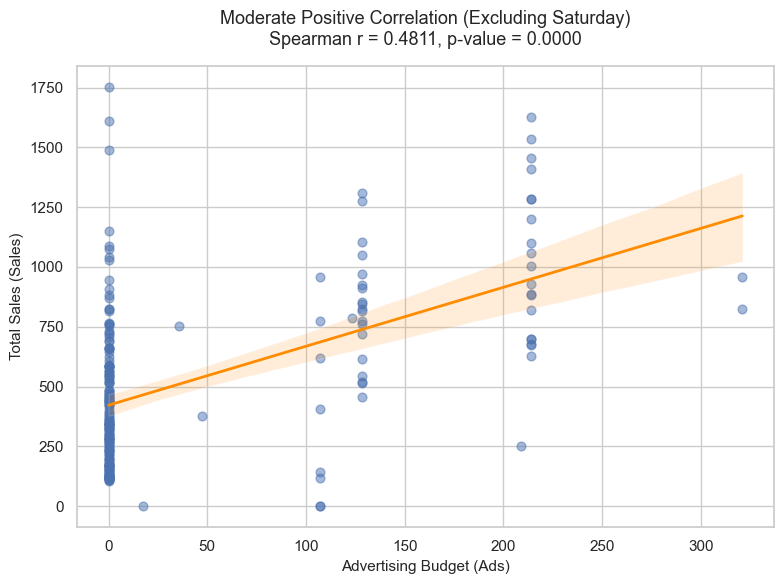

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. กรองข้อมูลเอาวันเสาร์ออก เพื่อให้ตรงกับผลสถิติล่าสุด
df_filtered = df[df["Day Name"] != "Saturday"].copy()

# 2. ตั้งค่าธีมและขนาดรูปเดี่ยว (ขนาดกำลังสวยสำหรับใส่ในเล่มวิจัย)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 3. พลอตกราฟ Linear Regression (เปลี่ยนเป็นสีน้ำเงิน/ฟ้า เพื่อความดูเป็นมืออาชีพ)
# เส้นแนวโน้ม (Regression Line) จะวิ่งเฉียงขึ้นตามค่า r = 0.4811
sns.regplot(
    x="Ads",
    y="Sales",
    data=df_filtered,
    color="b",
    scatter_kws={"alpha": 0.5, "s": 40},  # ปรับความโปร่งแสงและขนาดจุด
    line_kws={"color": "darkorange", "lw": 2},  # ไฮไลต์เส้นแนวโน้มด้วยสีส้มเข้ม
)

# 4. ใส่ชื่อเรื่องและชื่อแกนให้ถูกต้องตามผลสถิติจริง
plt.title(
    "Moderate Positive Correlation (Excluding Saturday)\nSpearman r = 0.4811, p-value = 0.0000",
    fontsize=13,
    pad=15,
)
plt.xlabel("Advertising Budget (Ads)", fontsize=11)
plt.ylabel("Total Sales (Sales)", fontsize=11)

plt.tight_layout()
plt.show()